# Reproducibility Testing — PICASO Error Cases

For each error category, re-run one case with `PICASO_climate_model` and compare the resulting PT profile
against what the h5 grid stored. This verifies the function is producing the same output as the original grid run.

**Test cases:**
- One BOA-error case (Photochem BOA boundary condition failure)
- One AssertionError case
- One EquilibrateException case
- One Photochem not-converged case
- One fully converged case (ground-truth check)

In [26]:
import sys, os, pickle
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import h5py

_root = Path.cwd()
sys.path.insert(0, str(_root / 'MiniNepGrid_Scripts'))
sys.path.insert(0, str(_root / 'ReflectedSpectra_Scripts'))

os.environ['picaso_refdata'] = str(_root / 'Installation&Setup_Instructions/picasofiles/reference')
os.environ['PYSYN_CDBS']     = str(_root / 'Installation&Setup_Instructions/picasofiles/grp/redcat/trds')

import PICASO_Climate_grid_121625 as picaso_grid

PICASO_H5    = 'data/grid_results/PICASO_climate_updatop_full_exploration_reducedrad_solveSegFault.h5'
PHOTOCHEM_H5 = 'data/grid_results/Photochem_1D_updatop_paramext_reducedrad_full_try3.h5'

In [27]:
# Grid parameter arrays — must match what was used to create both h5 files
pic_rad   = np.array([2.0])
pic_metal = np.linspace(0.5, 3.5, 9)
pic_tint  = np.linspace(50, 400, 8)
pic_semi  = np.array([0.3, 0.7, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0])
pic_ctoO  = np.linspace(0.01, 1.0, 5)
pc_kzz    = np.array([5.0, 7.0, 9.0])

# Load the full PICASO PT arrays from the h5 once
with h5py.File(PICASO_H5, 'r') as f:
    pic_P_all      = np.array(f['results']['pressure'])
    pic_T_all      = np.array(f['results']['temperature'])
    pic_status_all = np.array(f['results']['status'])

def _decode(val):
    return val.decode('utf-8') if isinstance(val, bytes) else str(val)

def get_PT_from_h5(params_5):
    """Look up the stored PICASO PT profile for a 5-param case.
    params_5: [rad, log10_metal, tint_K, semi_AU, ctoO]
    Returns P (bar), T (K) with NaNs stripped.
    """
    r, z, t, a, c = params_5
    r_i = np.argmin(np.abs(pic_rad   - r))
    m_i = np.argmin(np.abs(pic_metal - z))
    t_i = np.argmin(np.abs(pic_tint  - t))
    a_i = np.argmin(np.abs(pic_semi  - a))
    c_i = np.argmin(np.abs(pic_ctoO  - c))
    status = _decode(pic_status_all[r_i, m_i, t_i, a_i, c_i].flat[0])
    P = pic_P_all[r_i, m_i, t_i, a_i, c_i].flatten()
    T = pic_T_all[r_i, m_i, t_i, a_i, c_i].flatten()
    mask = ~np.isnan(P) & ~np.isnan(T) & (P > 0)
    return P[mask], T[mask], status, (r_i, m_i, t_i, a_i, c_i)

print('h5 loaded — PICASO shape:', pic_P_all.shape)

h5 loaded — PICASO shape: (1, 9, 8, 11, 5, 91)


In [28]:
# Load the saved .npy case lists from FailedCasesAudit.ipynb
# These files were saved in sorted order (smallest params first)
boa_cases = np.load('PICASOLimits_ReportFiles/picaso_inputs_caused_BOA_error.npy')   # shape (111, 5)
ae_cases  = np.load('PICASOLimits_ReportFiles/picaso_inputs_caused_AE_error.npy')    # shape (82, 5)
ee_cases  = np.load('PICASOLimits_ReportFiles/picaso_inputs_caused_EE_error.npy')    # shape (5, 5)
nc_cases  = np.load('PICASOLimits_ReportFiles/photochem_not_converged_cases.npy')    # shape (N, 6) — includes Kzz

# Pick the first case from each (index 0 = sorted-first, matching subplot [0,0] in FailedCasesAudit)
test_boa = boa_cases[0]
test_ae  = ae_cases[0]
test_ee  = ee_cases[0]
test_nc  = nc_cases[0]    # 6 params: [rad, metal, tint, semi, ctoO, Kzz]

print(f'BOA test case : {test_boa}')
print(f'AE  test case : {test_ae}')
print(f'EE  test case : {test_ee}')
print(f'NC  test case : {test_nc}  (6-param, includes Kzz)')

# Confirm each case exists in the h5 and show its stored status
for label, case in [('BOA', test_boa), ('AE', test_ae), ('EE', test_ee), ('NC', test_nc[:5])]:
    _, _, status, idx = get_PT_from_h5(case[:5])
    print(f'  {label}: h5 status = {status!r}  idx={idx}')

BOA test case : [2.00e+00 2.75e+00 5.00e+01 3.00e+00 1.00e-02]
AE  test case : [2.00e+00 2.75e+00 5.00e+01 2.00e+00 1.00e-02]
EE  test case : [  2.      3.125 350.      2.      0.505]
NC  test case : [2.e+00 5.e-01 5.e+01 5.e+00 1.e-02 9.e+00]  (6-param, includes Kzz)
  BOA: h5 status = 'converged'  idx=(0, 6, 0, 5, 0)
  AE: h5 status = 'converged'  idx=(0, 6, 0, 4, 0)
  EE: h5 status = 'converged'  idx=(0, 7, 6, 4, 2)
  NC: h5 status = 'converged'  idx=(0, 0, 0, 7, 0)


In [29]:
# Specific cases chosen by user for targeted re-run comparison.
# C/O grid values: np.linspace(0.01, 1.0, 5) = [0.01, 0.2575, 0.505, 0.7525, 1.0]
# Metal grid:      np.linspace(0.5, 3.5, 9)  (log10 solar)
# Tint grid:       np.linspace(50, 400, 8)   K
# semi grid:       [0.3, 0.7, 1, 1.5, 2, 3, 4, 5, 6, 8, 10]  AU

spec_case_1 = np.array([2.0, 3.5,  100.0, 0.3, 0.505 ])  # Z=3.5, Tint=100, semi=0.3, C/O=0.505
spec_case_2 = np.array([2.0, 2.75,  50.0, 6.0, 0.2575])  # Z=2.75, Tint=50, semi=6, C/O=0.2575
spec_case_3 = np.array([2.0, 2.75,  50.0, 5.0, 1.0   ])  # Z=2.75, Tint=50, semi=5, C/O=1
spec_case_4 = np.array([2.0, 3.5,  150.0, 6.0, 1.0   ])  # Z=3.5, Tint=150, semi=6, C/O=1

def find_error_type(case_5, tol=1e-4):
    """Check which .npy error file contains this 5-param case."""
    for label, arr in [('BOA', boa_cases), ('AE', ae_cases), ('EE', ee_cases)]:
        for row in arr:
            if np.allclose(row[:5], case_5, atol=tol):
                return label
    return 'unknown (not in BOA/AE/EE npy files)'

print('Specific cases to re-run:')
for name, case in [('spec_case_1', spec_case_1), ('spec_case_2', spec_case_2),
                   ('spec_case_3', spec_case_3), ('spec_case_4', spec_case_4)]:
    etype = find_error_type(case)
    _, _, h5st, idx = get_PT_from_h5(case)
    print(f'  {name}: {case}')
    print(f'           error type: {etype}  |  h5 PICASO status: {h5st!r}  |  h5 idx: {idx}')

Specific cases to re-run:
  spec_case_1: [  2.      3.5   100.      0.3     0.505]
           error type: BOA  |  h5 PICASO status: 'converged'  |  h5 idx: (0, 8, 1, 0, 2)
  spec_case_2: [ 2.      2.75   50.      6.      0.2575]
           error type: BOA  |  h5 PICASO status: 'converged'  |  h5 idx: (0, 6, 0, 8, 1)
  spec_case_3: [ 2.    2.75 50.    5.    1.  ]
           error type: AE  |  h5 PICASO status: 'converged'  |  h5 idx: (0, 6, 0, 7, 4)
  spec_case_4: [  2.    3.5 150.    6.    1. ]
           error type: EE  |  h5 PICASO status: 'converged'  |  h5 idx: (0, 8, 2, 8, 4)


In [30]:
# Find a fully converged case from the Photochem h5 to use as the ground-truth check
with h5py.File(PHOTOCHEM_H5, 'r') as f:
    pc_status_all = np.array(f['results']['status'])

conv_case = None
for r_i, rad in enumerate(pic_rad):
    for m_i, metal in enumerate(pic_metal):
        for t_i, tint in enumerate(pic_tint):
            for a_i, semi in enumerate(pic_semi):
                for c_i, ctoO in enumerate(pic_ctoO):
                    for k_i, kzz in enumerate(pc_kzz):
                        st = _decode(pc_status_all[r_i, m_i, t_i, a_i, c_i, k_i].flat[0])
                        if 'Photochem-converged' in st:
                            conv_case = np.array([float(rad), float(metal), float(tint),
                                                  float(semi), float(ctoO), float(kzz)])
                            break
                    if conv_case is not None:
                        break
                if conv_case is not None:
                    break
            if conv_case is not None:
                break
        if conv_case is not None:
            break
    if conv_case is not None:
        break

print(f'Converged test case: {conv_case}')
_, _, pic_status, _ = get_PT_from_h5(conv_case[:5])
print(f'  PICASO h5 status: {pic_status!r}')

Converged test case: [2.e+00 5.e-01 5.e+01 3.e-01 1.e-02 5.e+00]
  PICASO h5 status: 'converged'


In [31]:
os.makedirs('rerun_results', exist_ok=True)

def _pkl_path(case_5, suffix=''):
    r, z, t, a, c = case_5
    tag = f'_{suffix}' if suffix else ''
    return f'individual_rerun_data/grid_results/picaso_rerun_R{r}_Z{z}_T{t}_a{a}_CO{c}{tag}.pkl'

def compare_PT(case_5, label, color='steelblue', force_rerun=False, pkl_suffix=''):
    """Re-run PICASO for a 5-param case and compare to the h5 stored PT side by side.
    Saves the result to individual_rerun_data/grid_results/ as a pkl so future runs load instantly.
    Set force_rerun=True to re-run even if a saved pkl already exists.
    pkl_suffix: appended to the pkl filename as _{suffix} (e.g. 'v2' → _v2.pkl).
    """
    r, z, t, a, c = case_5
    print(f'\n── {label} ──────────────────────────────────────────')
    print(f'   rad={r}  Z={z}  Tint={t}  semi={a}  C/O={c}')

    # H5 stored profile for this exact case
    P_h5, T_h5, h5_status, _ = get_PT_from_h5(case_5)
    print(f'   h5 status  : {h5_status!r}')
    print(f'   h5 PT pts  : {len(P_h5)} levels')

    # Load from pkl if it exists, otherwise run PICASO and save
    pkl_file = _pkl_path(case_5, suffix=pkl_suffix)
    if not force_rerun and os.path.exists(pkl_file):
        print(f'   Loading saved result from {pkl_file}')
        with open(pkl_file, 'rb') as f:
            result = pickle.load(f)
    else:
        print(f'   Running PICASO_climate_model ...')
        result = picaso_grid.PICASO_climate_model(x=np.array(case_5))
        with open(pkl_file, 'wb') as f:
            pickle.dump(result, f)
        print(f'   Saved → {pkl_file}')

    rerun_status = result.get('status', b'')
    rerun_conv   = result.get('converged', None)
    rerun_err    = result.get('error', b'')
    if isinstance(rerun_status, bytes): rerun_status = rerun_status.decode()
    if isinstance(rerun_err,    bytes): rerun_err    = rerun_err.decode()
    print(f'   re-run status    : {rerun_status!r}')
    print(f'   re-run converged : {rerun_conv}')
    if rerun_err:
        print(f'   re-run error     : {rerun_err}')

    P_rr = np.atleast_1d(result.get('pressure',    np.array([])))
    T_rr = np.atleast_1d(result.get('temperature', np.array([])))
    mask_rr = ~np.isnan(P_rr) & ~np.isnan(T_rr) & (P_rr > 0)
    P_rr, T_rr = P_rr[mask_rr], T_rr[mask_rr]
    print(f'   re-run PT pts    : {len(P_rr)} levels')

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

    for ax, P, T, title in [
        (axes[0], P_h5, T_h5, f'h5 (grid run)\nstatus: {h5_status}'),
        (axes[1], P_rr, T_rr, f're-run (PICASO_climate_model)\nstatus: {rerun_status}'),
    ]:
        if len(P):
            ax.semilogy(T, P, color=color, lw=2)
        else:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=11, color='gray')
        ax.set_title(title, fontsize=9)
        ax.set_xlabel('T [K]')
        ax.minorticks_on()
        ax.grid(alpha=0.2)

    # invert_yaxis called ONCE on the shared axis — calling once per axis in the loop
    # would toggle the shared y-axis twice (cancelling out with sharey=True)
    axes[0].invert_yaxis()
    axes[0].set_ylabel('P [bar]')
    plt.suptitle(f'{label}  —  rad={r} Z={z} Tint={t} semi={a} C/O={c}', fontsize=10)
    plt.tight_layout()
    fname = f'individual_rerun_data/grid_results/test_PT_{label.replace(" ", "_")}.png'
    plt.savefig(fname, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'   Plot saved → {fname}')
    return result


def compare_PT_three_way(case_5, label, color='steelblue', force_rerun_2=False):
    """Three-way PT comparison: h5 grid run | local re-run 1 | local re-run 2.
    Re-run 1 is loaded from the existing pkl (no suffix).
    Re-run 2 is a fresh PICASO call saved with suffix 'v2' — runs only if pkl absent.
    Use force_rerun_2=True to force a new second run.
    """
    r, z, t, a, c = case_5
    print(f'\n── THREE-WAY: {label} ──────────────────────────')
    print(f'   Testing non-determinism: rad={r} Z={z} Tint={t} semi={a} C/O={c}')

    # H5 profile
    P_h5, T_h5, h5_status, _ = get_PT_from_h5(case_5)
    print(f'   h5 status: {h5_status!r}  ({len(P_h5)} levels)')

    # Re-run 1: load existing pkl (no suffix); run if missing
    pkl_1 = _pkl_path(case_5, suffix='')
    if os.path.exists(pkl_1):
        print(f'   Re-run 1: loading from {pkl_1}')
        with open(pkl_1, 'rb') as f:
            result_1 = pickle.load(f)
    else:
        print(f'   Re-run 1: pkl not found — running PICASO ...')
        result_1 = picaso_grid.PICASO_climate_model(x=np.array(case_5))
        with open(pkl_1, 'wb') as f:
            pickle.dump(result_1, f)
        print(f'   Re-run 1: saved → {pkl_1}')

    # Re-run 2: fresh PICASO call, saved with _v2 suffix
    pkl_2 = _pkl_path(case_5, suffix='v2')
    if not force_rerun_2 and os.path.exists(pkl_2):
        print(f'   Re-run 2: loading from {pkl_2}')
        with open(pkl_2, 'rb') as f:
            result_2 = pickle.load(f)
    else:
        print(f'   Re-run 2: running PICASO fresh (this may take a few minutes)...')
        result_2 = picaso_grid.PICASO_climate_model(x=np.array(case_5))
        with open(pkl_2, 'wb') as f:
            pickle.dump(result_2, f)
        print(f'   Re-run 2: saved → {pkl_2}')

    def _status(res):
        s = res.get('status', b'')
        return s.decode() if isinstance(s, bytes) else str(s)

    def _extract(res):
        P = np.atleast_1d(res.get('pressure', np.array([])))
        T = np.atleast_1d(res.get('temperature', np.array([])))
        mask = ~np.isnan(P) & ~np.isnan(T) & (P > 0)
        return P[mask], T[mask]

    P_rr1, T_rr1 = _extract(result_1)
    P_rr2, T_rr2 = _extract(result_2)
    st1 = _status(result_1)
    st2 = _status(result_2)
    print(f'   Re-run 1 status: {st1!r}  ({len(P_rr1)} levels)')
    print(f'   Re-run 2 status: {st2!r}  ({len(P_rr2)} levels)')

    fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
    pairs = [
        (axes[0], P_h5,  T_h5,  f'Grid (h5, Hyak)\nstatus: {h5_status}'),
        (axes[1], P_rr1, T_rr1, f'Local re-run 1\nstatus: {st1}'),
        (axes[2], P_rr2, T_rr2, f'Local re-run 2\nstatus: {st2}'),
    ]
    for ax, P, T, title in pairs:
        if len(P):
            ax.semilogy(T, P, color=color, lw=2)
        else:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=11, color='gray')
        ax.set_title(title, fontsize=9)
        ax.set_xlabel('T [K]')
        ax.minorticks_on()
        ax.grid(alpha=0.2)
    axes[0].invert_yaxis()  # single call on the shared axis
    axes[0].set_ylabel('P [bar]')

    # Overlay panel on a separate figure for direct comparison
    fig2, ax2 = plt.subplots(figsize=(5, 5))
    for P, T, lbl, ls in [
        (P_h5,  T_h5,  f'h5 grid ({h5_status})',   '-'),
        (P_rr1, T_rr1, f're-run 1 ({st1})', '--'),
        (P_rr2, T_rr2, f're-run 2 ({st2})', ':'),
    ]:
        if len(P):
            ax2.semilogy(T, P, lw=2, linestyle=ls, label=lbl)
    ax2.invert_yaxis()
    ax2.set_xlabel('T [K]'); ax2.set_ylabel('P [bar]')
    ax2.legend(fontsize=8); ax2.minorticks_on(); ax2.grid(alpha=0.2)
    ax2.set_title('Overlay — solver non-determinism check', fontsize=9)
    fig2.tight_layout()

    plt.figure(fig.number)
    plt.suptitle(
        f'{label}\nrad={r}  Z={z}  Tint={t}  semi={a}  C/O={c}  '
        f'— non-determinism test (h5 Hyak vs two local re-runs)', fontsize=9)
    plt.tight_layout()

    fname_panels  = f'individual_rerun_data/grid_results/test_PT_{label.replace(" ","_")}_threeway.png'
    fname_overlay = f'individual_rerun_data/grid_results/test_PT_{label.replace(" ","_")}_overlay.png'
    fig.savefig(fname_panels,  dpi=120, bbox_inches='tight')
    fig2.savefig(fname_overlay, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'   Panels  → {fname_panels}')
    print(f'   Overlay → {fname_overlay}')
    return result_1, result_2


## Error Cases — PICASO Re-Run vs H5


── Spec case 1 (Z=3.5 Tint=100 semi=0.3 CO=0.505) ──────────────────────────────────────────
   rad=2.0  Z=3.5  Tint=100.0  semi=0.3  C/O=0.505
   h5 status  : 'converged'
   h5 PT pts  : 91 levels
   Loading saved result from individual_rerun_data/grid_results/picaso_rerun_R2.0_Z3.5_T100.0_a0.3_CO0.505.pkl
   re-run status    : array([b'converged'], dtype='|S9')
   re-run converged : [[1]]
   re-run PT pts    : 91 levels


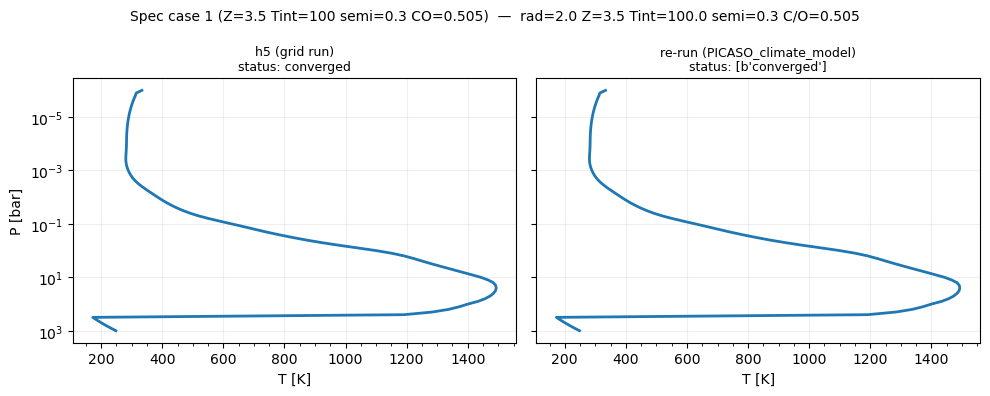

   Plot saved → individual_rerun_data/grid_results/test_PT_Spec_case_1_(Z=3.5_Tint=100_semi=0.3_CO=0.505).png


In [32]:
# spec_case_1: Z=3.5, Tint=100, semi=0.3, C/O=0.505
result_spec1 = compare_PT(spec_case_1, 'Spec case 1 (Z=3.5 Tint=100 semi=0.3 CO=0.505)', color='#1f77b4')


── Spec case 2 (Z=2.75 Tint=50 semi=6 CO=0.2575) ──────────────────────────────────────────
   rad=2.0  Z=2.75  Tint=50.0  semi=6.0  C/O=0.2575
   h5 status  : 'converged'
   h5 PT pts  : 91 levels
   Loading saved result from individual_rerun_data/grid_results/picaso_rerun_R2.0_Z2.75_T50.0_a6.0_CO0.2575.pkl
   re-run status    : array([b'converged'], dtype='|S9')
   re-run converged : [[1]]
   re-run PT pts    : 91 levels


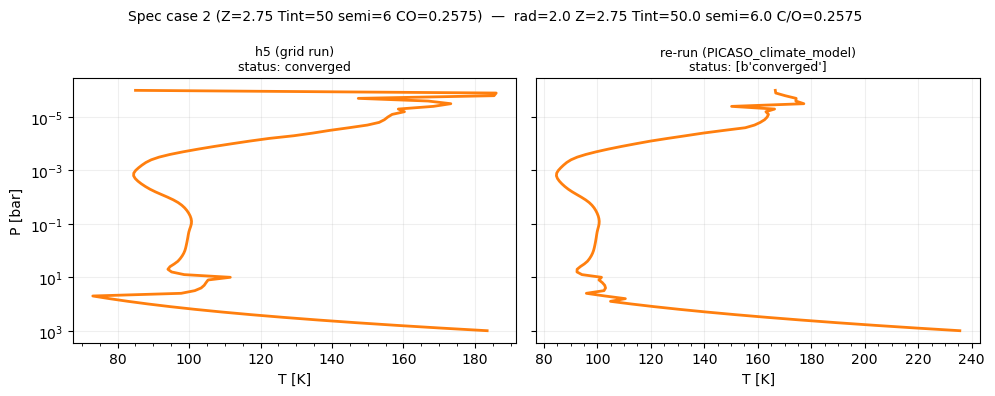

   Plot saved → individual_rerun_data/grid_results/test_PT_Spec_case_2_(Z=2.75_Tint=50_semi=6_CO=0.2575).png


In [33]:
# spec_case_2: Z=2.75, Tint=50, semi=6, C/O=0.2575
result_spec2 = compare_PT(spec_case_2, 'Spec case 2 (Z=2.75 Tint=50 semi=6 CO=0.2575)', color='#ff7f0e')


── Spec case 3 (Z=2.75 Tint=50 semi=5 CO=1) ──────────────────────────────────────────
   rad=2.0  Z=2.75  Tint=50.0  semi=5.0  C/O=1.0
   h5 status  : 'converged'
   h5 PT pts  : 91 levels
   Loading saved result from individual_rerun_data/grid_results/picaso_rerun_R2.0_Z2.75_T50.0_a5.0_CO1.0.pkl
   re-run status    : array([b'converged'], dtype='|S9')
   re-run converged : [[1]]
   re-run PT pts    : 91 levels


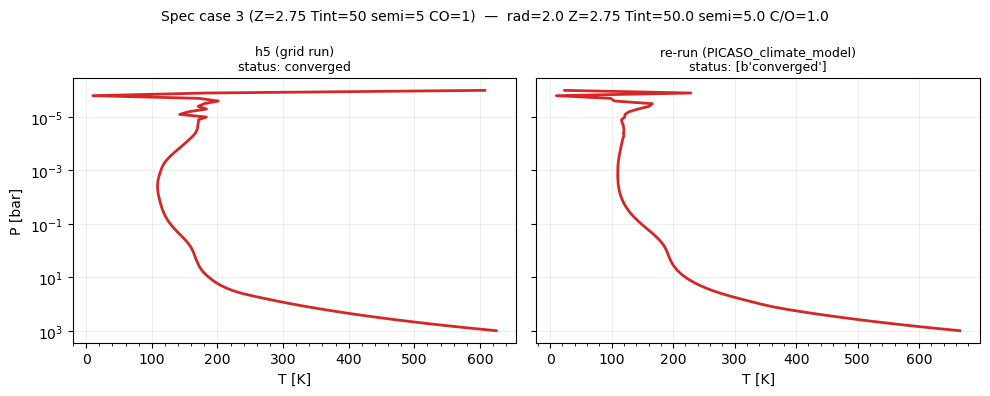

   Plot saved → individual_rerun_data/grid_results/test_PT_Spec_case_3_(Z=2.75_Tint=50_semi=5_CO=1).png


In [34]:
# spec_case_3: Z=2.75, Tint=50, semi=5, C/O=1
result_spec3 = compare_PT(spec_case_3, 'Spec case 3 (Z=2.75 Tint=50 semi=5 CO=1)', color='#d62728')


── Spec case 4 (Z=3.5 Tint=150 semi=6 CO=1) ──────────────────────────────────────────
   rad=2.0  Z=3.5  Tint=150.0  semi=6.0  C/O=1.0
   h5 status  : 'converged'
   h5 PT pts  : 91 levels
   Loading saved result from individual_rerun_data/grid_results/picaso_rerun_R2.0_Z3.5_T150.0_a6.0_CO1.0.pkl
   re-run status    : array([b'error'], dtype='|S5')
   re-run converged : [0]
   re-run error     : [b'ZeroDivisionError: division by zero']
   re-run PT pts    : 0 levels


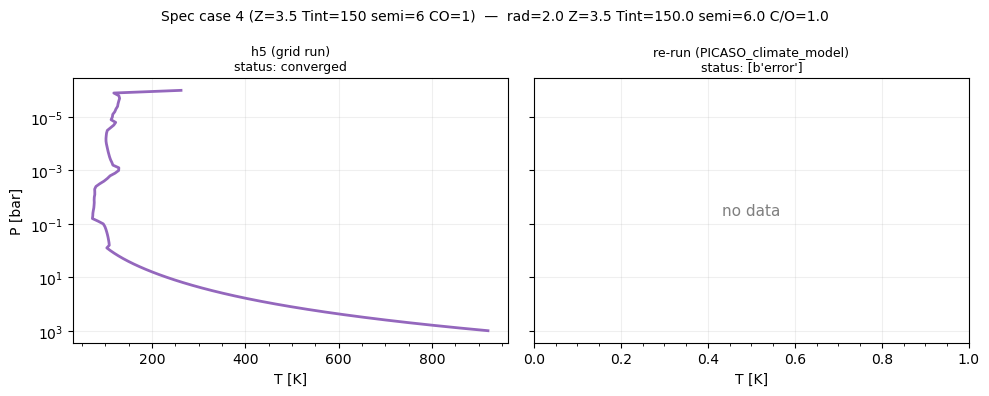

   Plot saved → individual_rerun_data/grid_results/test_PT_Spec_case_4_(Z=3.5_Tint=150_semi=6_CO=1).png


In [35]:
# spec_case_4: Z=3.5, Tint=150, semi=6, C/O=1
result_spec4 = compare_PT(spec_case_4, 'Spec case 4 (Z=3.5 Tint=150 semi=6 CO=1)', color='#9467bd')


── Photochem not-converged case ──────────────────────────────────────────
   rad=2.0  Z=0.5  Tint=50.0  semi=5.0  C/O=0.01
   h5 status  : 'converged'
   h5 PT pts  : 91 levels
   Loading saved result from individual_rerun_data/grid_results/picaso_rerun_R2.0_Z0.5_T50.0_a5.0_CO0.01.pkl
   re-run status    : array([b'converged'], dtype='|S9')
   re-run converged : [[1]]
   re-run PT pts    : 91 levels


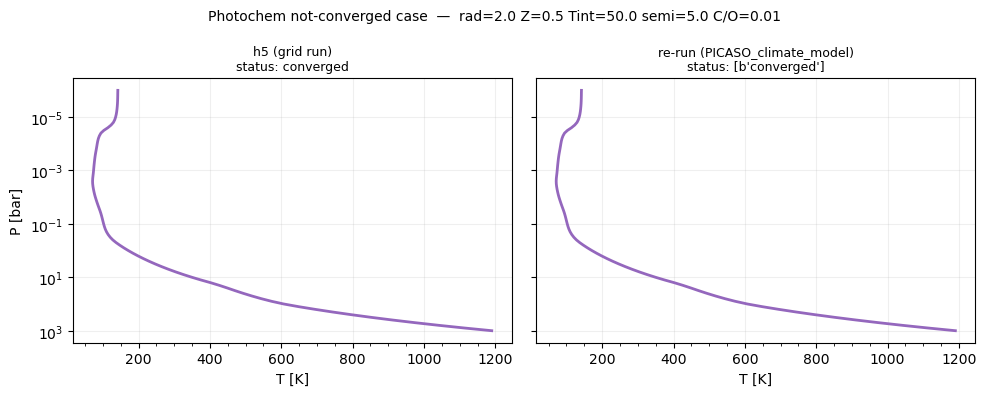

   Plot saved → individual_rerun_data/grid_results/test_PT_Photochem_not-converged_case.png


In [36]:
# Not-converged case — PICASO part uses only the first 5 params (no Kzz)
result_nc = compare_PT(test_nc[:5], 'Photochem not-converged case', color='#9467bd')

## Ground-Truth Check — Fully Converged Case

Both PICASO and Photochem converged for this case. We compare the PICASO PT from the h5
against a fresh re-run to verify the function is still producing the same profile as the grid.


── Converged case (ground truth) ──────────────────────────────────────────
   rad=2.0  Z=0.5  Tint=50.0  semi=0.3  C/O=0.01
   h5 status  : 'converged'
   h5 PT pts  : 91 levels
   Loading saved result from individual_rerun_data/grid_results/picaso_rerun_R2.0_Z0.5_T50.0_a0.3_CO0.01.pkl
   re-run status    : array([b'converged'], dtype='|S9')
   re-run converged : [[1]]
   re-run PT pts    : 91 levels


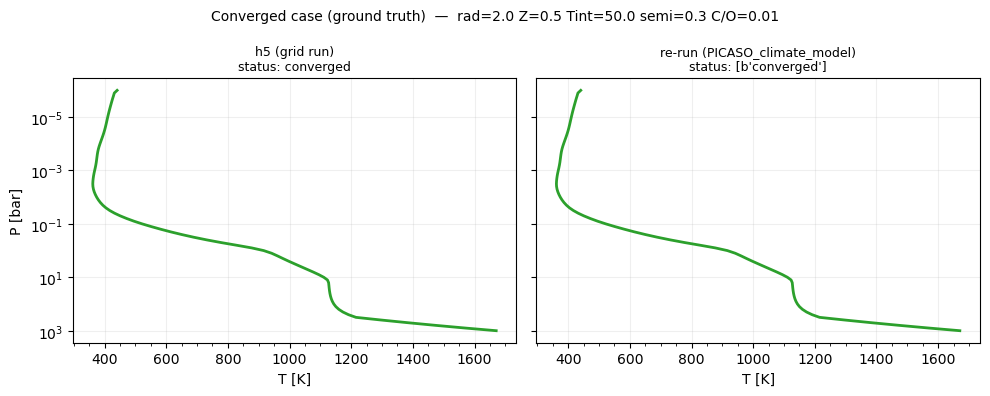

   Plot saved → individual_rerun_data/grid_results/test_PT_Converged_case_(ground_truth).png


In [37]:
result_conv = compare_PT(conv_case[:5], 'Converged case (ground truth)', color='#2ca02c')

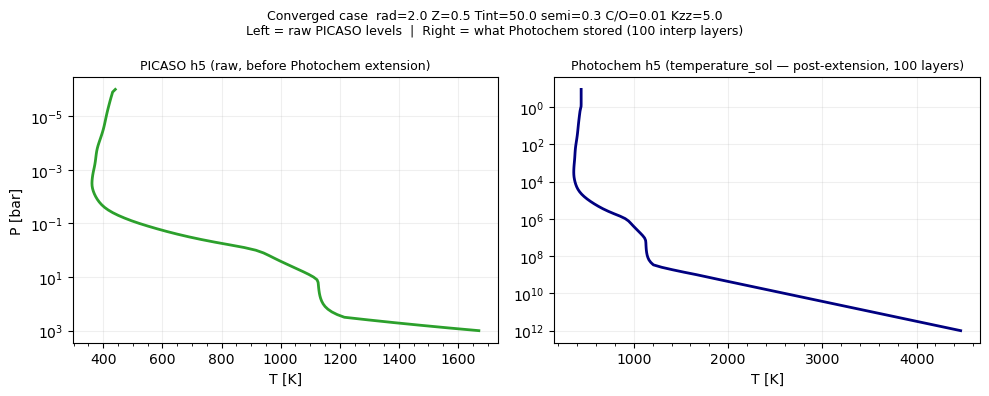

Note: the right panel extends deeper (linear_extrapolate_TP added high-P tail) and is interpolated to 100 log-spaced levels.


In [38]:
# Also compare PT against the Photochem h5 for the converged case
# The Photochem h5 stores temperature_sol — the PT that Photochem actually ran with
# (after linear_extrapolate_TP + unit conversion + interpolation to 100 layers)

r_i = np.argmin(np.abs(pic_rad   - conv_case[0]))
m_i = np.argmin(np.abs(pic_metal - conv_case[1]))
t_i = np.argmin(np.abs(pic_tint  - conv_case[2]))
a_i = np.argmin(np.abs(pic_semi  - conv_case[3]))
c_i = np.argmin(np.abs(pic_ctoO  - conv_case[4]))
k_i = np.argmin(np.abs(pc_kzz   - conv_case[5]))

with h5py.File(PHOTOCHEM_H5, 'r') as f:
    P_pc_h5 = np.array(f['results']['pressure_sol'][r_i, m_i, t_i, a_i, c_i, k_i])
    T_pc_h5 = np.array(f['results']['temperature_sol'][r_i, m_i, t_i, a_i, c_i, k_i])

# Raw PICASO PT for same case
P_pic_h5, T_pic_h5, _, _ = get_PT_from_h5(conv_case[:5])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].semilogy(T_pic_h5, P_pic_h5, color='#2ca02c', lw=2)
axes[0].invert_yaxis()
axes[0].set_title('PICASO h5 (raw, before Photochem extension)', fontsize=9)
axes[0].set_xlabel('T [K]'); axes[0].set_ylabel('P [bar]')
axes[0].minorticks_on(); axes[0].grid(alpha=0.2)

mask = ~np.isnan(P_pc_h5) & ~np.isnan(T_pc_h5) & (P_pc_h5 > 0)
axes[1].semilogy(T_pc_h5[mask], P_pc_h5[mask], color='navy', lw=2)
axes[1].invert_yaxis()
axes[1].set_title('Photochem h5 (temperature_sol — post-extension, 100 layers)', fontsize=9)
axes[1].set_xlabel('T [K]')
axes[1].minorticks_on(); axes[1].grid(alpha=0.2)

r, z, t, a, c, k = conv_case
plt.suptitle(f'Converged case  rad={r} Z={z} Tint={t} semi={a} C/O={c} Kzz={k}\n'
             f'Left = raw PICASO levels  |  Right = what Photochem stored (100 interp layers)',
             fontsize=9)
plt.tight_layout()
plt.savefig('test_PT_converged_PICASO_vs_Photochem.png', dpi=120, bbox_inches='tight')
plt.show()
print('Note: the right panel extends deeper (linear_extrapolate_TP added high-P tail) and is '
      'interpolated to 100 log-spaced levels.')

## Specific Case Re-Run — H2/He-Rich Mini-Neptune
`rad=2, Z=2.0 (log10, ~100× solar), Tint=50 K, semi=1 AU, C/O=0.7525, Kzz=5`

H2He-rich case PICASO h5 status : 'converged'
H2He-rich case h5 grid index    : (0, 4, 0, 2, 3)

── H2He-rich MiniNep (Z=2 Tint=50 semi=1 CO=0.7525) ──────────────────────────────────────────
   rad=2.0  Z=2.0  Tint=50.0  semi=1.0  C/O=0.7525
   h5 status  : 'converged'
   h5 PT pts  : 91 levels
   Loading saved result from individual_rerun_data/grid_results/picaso_rerun_R2.0_Z2.0_T50.0_a1.0_CO0.7525.pkl
   re-run status    : array([b'converged'], dtype='|S9')
   re-run converged : [[1]]
   re-run PT pts    : 91 levels


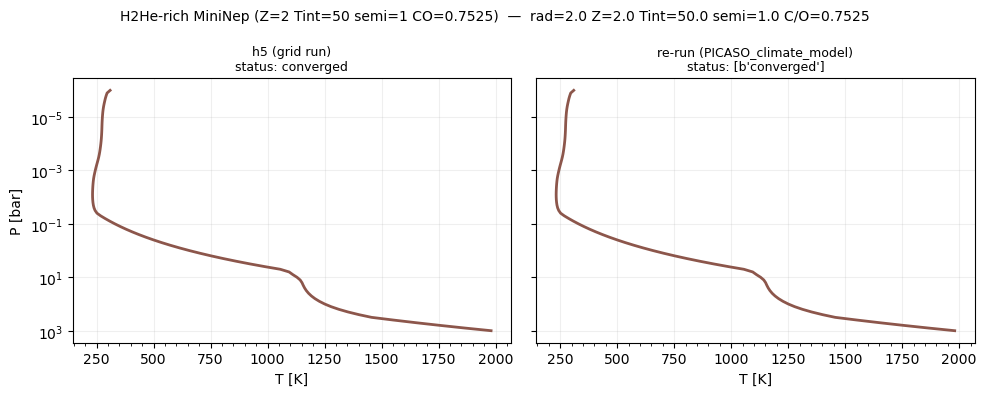

   Plot saved → individual_rerun_data/grid_results/test_PT_H2He-rich_MiniNep_(Z=2_Tint=50_semi=1_CO=0.7525).png


In [39]:
h2he_case = np.array([2.0, 2.0, 50.0, 1.0, 0.7525])  # 5 PICASO params (Kzz=5 is Photochem-only)

# Check what the h5 stored for this case before re-running
_, _, h2he_h5_status, h2he_idx = get_PT_from_h5(h2he_case)
print(f'H2He-rich case PICASO h5 status : {h2he_h5_status!r}')
print(f'H2He-rich case h5 grid index    : {h2he_idx}')

result_h2he = compare_PT(h2he_case, 'H2He-rich MiniNep (Z=2 Tint=50 semi=1 CO=0.7525)', color='#8c564b')

## Non-Determinism Test — BOA Error Case [2.0, 2.75, 50.0, 3.0, 0.01]

This is the case from `FailedCasesAudit.ipynb` where the h5 PT (Part 1) and the pkl re-run (Part 3) did not visually match despite being confirmed as the same input parameters.

- **Re-run 1**: `out_[2.00e+00 2.75e+00 5.00e+01 3.00e+00 1.00e-02].pkl` — the pkl created in `FailedCasesAudit.ipynb` (not overwritten here)
- **Re-run 2**: a fresh PICASO call saved to `individual_rerun_data/grid_results/` with a `_v2` suffix

If re-run 1 and re-run 2 agree with each other but differ from h5 → hardware/floating-point divergence between Hyak and local machine.  
If re-run 1 and re-run 2 also differ from each other → solver genuinely non-deterministic for this case.

Re-run 1: loading from out_[2.00e+00 2.75e+00 5.00e+01 3.00e+00 1.00e-02].pkl
  keys: ['pressure', 'temperature', 'converged', 'status', 'error']
  status: [b'converged']
  converged: [[1]]

Re-run 2: loading cached pkl from individual_rerun_data/grid_results/picaso_rerun_R2.0_Z2.75_T50.0_a3.0_CO0.01_v2.pkl

h5 status: 'converged'  (91 levels)
re-run 1 status: "[b'converged']"  (91 levels)
re-run 2 status: "[b'converged']"  (91 levels)


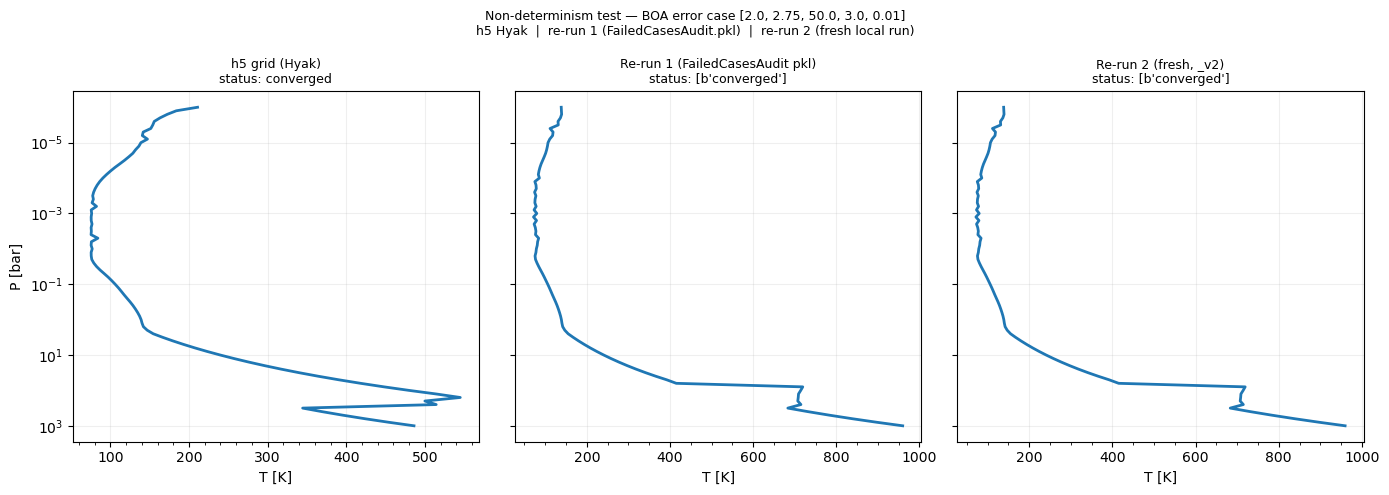

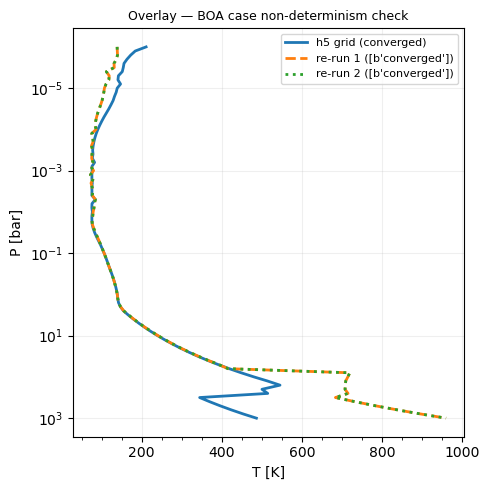

Saved → individual_rerun_data/grid_results/test_PT_BOA_nondet_threeway.png
Saved → individual_rerun_data/grid_results/test_PT_BOA_nondet_overlay.png


In [40]:
boa_nondet_case = np.array([2.0, 2.75, 50.0, 3.0, 0.01])

# Re-run 1: existing pkl from FailedCasesAudit — load only, never overwrite
pkl_existing = 'individual_rerun_data/grid_results/out_[2.00e+00 2.75e+00 5.00e+01 3.00e+00 1.00e-02].pkl'
if not os.path.exists(pkl_existing):
    raise FileNotFoundError(f'Expected pkl not found: {pkl_existing}\n'
                            'Make sure it was created in FailedCasesAudit.ipynb and the '
                            'notebook is run from the project root.')
print(f'Re-run 1: loading from {pkl_existing}')
with open(pkl_existing, 'rb') as f:
    result_boa_1 = pickle.load(f)
print(f'  keys: {list(result_boa_1.keys())}')
print(f'  status: {result_boa_1.get("status", "n/a")}')
print(f'  converged: {result_boa_1.get("converged", "n/a")}')

# Re-run 2: fresh PICASO call saved with _v2 suffix — original pkl untouched
pkl_v2 = _pkl_path(boa_nondet_case, suffix='v2')
if os.path.exists(pkl_v2):
    print(f'\nRe-run 2: loading cached pkl from {pkl_v2}')
    with open(pkl_v2, 'rb') as f:
        result_boa_2 = pickle.load(f)
else:
    print(f'\nRe-run 2: running PICASO fresh (this may take a few minutes)...')
    result_boa_2 = picaso_grid.PICASO_climate_model(x=boa_nondet_case)
    with open(pkl_v2, 'wb') as f:
        pickle.dump(result_boa_2, f)
    print(f'  Saved → {pkl_v2}')

# H5 stored PT for this exact case
P_h5_boa, T_h5_boa, h5st_boa, _ = get_PT_from_h5(boa_nondet_case)
print(f'\nh5 status: {h5st_boa!r}  ({len(P_h5_boa)} levels)')

def _st(res):
    s = res.get('status', b'')
    return s.decode() if isinstance(s, bytes) else str(s)

def _extract_PT(res):
    P = np.atleast_1d(res.get('pressure', np.array([])))
    T = np.atleast_1d(res.get('temperature', np.array([])))
    mask = ~np.isnan(P) & ~np.isnan(T) & (P > 0)
    return P[mask], T[mask]

P_rr1, T_rr1 = _extract_PT(result_boa_1)
P_rr2, T_rr2 = _extract_PT(result_boa_2)
st1, st2 = _st(result_boa_1), _st(result_boa_2)
print(f're-run 1 status: {st1!r}  ({len(P_rr1)} levels)')
print(f're-run 2 status: {st2!r}  ({len(P_rr2)} levels)')

# 3-panel side-by-side
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
c = '#1f77b4'
for ax, P, T, title in [
    (axes[0], P_h5_boa, T_h5_boa, f'h5 grid (Hyak)\nstatus: {h5st_boa}'),
    (axes[1], P_rr1,    T_rr1,    f'Re-run 1 (FailedCasesAudit pkl)\nstatus: {st1}'),
    (axes[2], P_rr2,    T_rr2,    f'Re-run 2 (fresh, _v2)\nstatus: {st2}'),
]:
    if len(P):
        ax.semilogy(T, P, color=c, lw=2)
    else:
        ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                transform=ax.transAxes, fontsize=11, color='gray')
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('T [K]')
    ax.minorticks_on(); ax.grid(alpha=0.2)
axes[0].invert_yaxis()  # single call on the shared axis
axes[0].set_ylabel('P [bar]')
plt.suptitle('Non-determinism test — BOA error case [2.0, 2.75, 50.0, 3.0, 0.01]\n'
             'h5 Hyak  |  re-run 1 (FailedCasesAudit.pkl)  |  re-run 2 (fresh local run)',
             fontsize=9)
plt.tight_layout()
plt.savefig('individual_rerun_data/grid_results/test_PT_BOA_nondet_threeway.png', dpi=120, bbox_inches='tight')
plt.show()

# Overlay for direct comparison
fig2, ax2 = plt.subplots(figsize=(5, 5))
for P, T, lbl, ls in [
    (P_h5_boa, T_h5_boa, f'h5 grid ({h5st_boa})', '-'),
    (P_rr1,    T_rr1,    f're-run 1 ({st1})',      '--'),
    (P_rr2,    T_rr2,    f're-run 2 ({st2})',      ':'),
]:
    if len(P):
        ax2.semilogy(T, P, lw=2, linestyle=ls, label=lbl)
ax2.invert_yaxis()
ax2.set_xlabel('T [K]'); ax2.set_ylabel('P [bar]')
ax2.legend(fontsize=8); ax2.minorticks_on(); ax2.grid(alpha=0.2)
ax2.set_title('Overlay — BOA case non-determinism check', fontsize=9)
fig2.tight_layout()
fig2.savefig('individual_rerun_data/grid_results/test_PT_BOA_nondet_overlay.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → individual_rerun_data/grid_results/test_PT_BOA_nondet_threeway.png')
print('Saved → individual_rerun_data/grid_results/test_PT_BOA_nondet_overlay.png')
